# Fine-tuning SLM untuk Chatbot Tim Legal berbasis RAG

**Peserta**: Nazhif Setya Nugroho
**Program**: Dicoding — Pengembangan Generative AI Berbasis LLM (PGABL)
**Target level**: Advanced ⭐⭐⭐⭐⭐

## Overview

Notebook ini melakukan **Supervised Fine-Tuning (SFT)** pada Small Language Model **Llama-3.2-3B-Instruct** menggunakan **QLoRA 4-bit** via **Unsloth** untuk membangun otak percakapan chatbot legal internal. Fine-tuning mengajarkan model berkomunikasi dalam Bahasa Indonesia formal dengan gaya instruction-following — **pengetahuan hukum spesifik disuntikkan via RAG (dokumen 4 PDF regulasi) pada tahap inference, bukan dihafal ke bobot model**. Pemisahan ini penting: model tetap general-purpose untuk Bahasa Indonesia, sementara *ground truth* legal selalu grounded ke dokumen resmi melalui retrieval.

## Cakupan (K1 — Fine-tuning)

- **Basic**: Load model + QLoRA 4-bit + LoRA di MHA + FFN + chat template Llama-3 via `datasets.map()` + SFTTrainer 800 steps + push ke Hugging Face Hub sebagai `merged_16bit`.
- **Skilled**: Split train/val stratified + `eval_strategy="steps"` + **2 eksperimen** dengan hyperparameter berbeda + analisis komparatif (train/eval loss).

**Advanced (GRPO)** ada di notebook terpisah: `GRPO_submission_PGABL_Nazhif_Setya_Nugroho.ipynb`.

## Dataset

- **`Ichsan2895/alpaca-gpt4-indonesian`** (2 kolom: `input`, `output`, ~49,969 rows).
- Sudah disiapkan sebelumnya: split 90/10 stratified by input length bucket, chat template Llama-3 applied via `datasets.map()`, disimpan sebagai JSONL di Google Drive.

## Prasyarat runtime

1. Colab **T4 GPU** (16 GB VRAM).
2. Colab Secrets: `HF_TOKEN` (scope Write), `WANDB_API_KEY`.
3. Google Drive mounted — mengandung dataset ter-format dari tahap persiapan.
4. Package terinstall: `unsloth`, `trl`, `transformers`, `datasets`, `peft`, `wandb`.

## Resume-safe workflow

Notebook ini idempoten dan resume-safe. Semua state (adapter, log_history, checkpoint intermediate setiap 200 steps) tersimpan ke Google Drive:
- Jika notebook di-run ulang dan adapter final sudah ada → experiment akan **skip** (loading result yang sudah tersimpan).
- Jika notebook di-run ulang dan hanya ada checkpoint intermediate → training **auto-resume** dari checkpoint terakhir, tidak dari step 0.

**Estimasi waktu Run All**: ~90-120 menit fresh (2 eksperimen × ~40-50 menit + upload HF ~5-10 menit). Kalau resume dari checkpoint, jauh lebih cepat.

---

## Section 1 — Setup Environment

In [1]:
import os, sys, json, gc, random, time, subprocess
from pathlib import Path

assert 'google.colab' in sys.modules, 'Notebook ini didesain untuk Google Colab T4.'

from google.colab import userdata, drive

HF_TOKEN = userdata.get('HF_TOKEN')
WANDB_API_KEY = userdata.get('WANDB_API_KEY')
assert HF_TOKEN, 'HF_TOKEN tidak ditemukan di Colab Secrets.'
assert WANDB_API_KEY, 'WANDB_API_KEY tidak ditemukan di Colab Secrets.'

os.environ['HF_TOKEN'] = HF_TOKEN
os.environ['HUGGINGFACE_TOKEN'] = HF_TOKEN
os.environ['WANDB_API_KEY'] = WANDB_API_KEY
os.environ['WANDB_PROJECT'] = 'PGABL-SFT'

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/PGABL')
SFT_DATA_DIR = DRIVE_ROOT / 'data' / 'processed' / 'sft'
CHECKPOINTS_DIR = DRIVE_ROOT / 'checkpoints' / 'sft'
EVIDENCE_DIR = DRIVE_ROOT / 'outputs' / 'finetune_evidence'
for d in (CHECKPOINTS_DIR, EVIDENCE_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)

print(f'HF_TOKEN loaded (starts with {HF_TOKEN[:6]}...)')
print(f'SFT data dir: {SFT_DATA_DIR}')
print(f'Checkpoints dir: {CHECKPOINTS_DIR}')
print(f'Seed: {SEED}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HF_TOKEN loaded (starts with hf_bRo...)
SFT data dir: /content/drive/MyDrive/PGABL/data/processed/sft
Checkpoints dir: /content/drive/MyDrive/PGABL/checkpoints/sft
Seed: 42


In [2]:
# Defensive install (jika notebook di-run standalone tanpa 00_setup_verify)
import importlib

required_packages = ['unsloth', 'trl', 'transformers', 'datasets', 'peft', 'wandb']
missing = [p for p in required_packages if importlib.util.find_spec(p) is None]

if missing:
    print(f'Installing missing packages: {missing}')
    !pip install -q "unsloth[colab-new]"
    !pip install -q wandb
    print('\n' + '='*60)
    print('INSTALL DONE. Runtime perlu di-restart supaya versi baru ter-load.')
    print('Menu: Runtime -> Restart runtime, lalu Run All lagi.')
    print('Cell ini akan otomatis skip install saat re-run.')
    print('='*60)
    # Force kernel restart (Colab akan auto-reconnect)
    os.kill(os.getpid(), 9)

print('All required packages present.')

All required packages present.


In [3]:
import torch
import numpy as np
from datasets import load_dataset, Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from transformers import AutoTokenizer, set_seed
import wandb

set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), 'CUDA tidak tersedia. Runtime → Change runtime type → T4 GPU.'

print(f'torch: {torch.__version__}')
print(f'CUDA device: {torch.cuda.get_device_name(0)}')
print(f'CUDA capability: {torch.cuda.get_device_capability(0)}')
!nvidia-smi --query-gpu=memory.total,memory.free --format=csv,noheader

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


Accessing `is_flash_linear_attention_available` from `.models.aria.image_processing_aria`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.aria.image_processing_pil_aria`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.auto.image_processing_auto`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.beit.image_processing_beit`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.beit.image_processing_pil_beit`. R

🦥 Unsloth Zoo will now patch everything to make training faster!
torch: 2.10.0+cu128
CUDA device: Tesla T4
CUDA capability: (7, 5)
15360 MiB, 14758 MiB


In [4]:
# Login HuggingFace + Weights & Biases
from huggingface_hub import login as hf_login, HfApi

hf_login(token=HF_TOKEN, add_to_git_credential=False)
hf_api = HfApi()
hf_user_info = hf_api.whoami()
HF_USERNAME = hf_user_info['name']
print(f'HuggingFace login OK sebagai: {HF_USERNAME}')

wandb.login(key=WANDB_API_KEY)
print('Weights & Biases login OK')

HuggingFace login OK sebagai: nazhifsetya-merpati


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nazhif-sn (nazhif-sn-merpati) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Weights & Biases login OK


---

## Section 2 — Load Dataset

Dataset sudah disiapkan pada tahap persiapan data: split 90/10 stratified by input length bucket, chat template Llama-3 sudah applied via `datasets.map()`. Setiap baris JSONL berisi field `text` dengan format Llama-3 chat template lengkap.

In [5]:
train_path = SFT_DATA_DIR / 'train.jsonl'
val_path = SFT_DATA_DIR / 'val.jsonl'

assert train_path.exists(), f'File tidak ditemukan: {train_path}. Jalankan notebook persiapan dataset dulu.'
assert val_path.exists(), f'File tidak ditemukan: {val_path}.'

train_ds = load_dataset('json', data_files=str(train_path), split='train')
val_ds = load_dataset('json', data_files=str(val_path), split='train')

print(f'Train: {len(train_ds):,} rows')
print(f'Val:   {len(val_ds):,} rows')
print(f'Columns: {train_ds.column_names}')

# Subsample val untuk during-training eval (biar tidak terlalu lambat)
VAL_EVAL_SUBSET_SIZE = 200
val_ds_eval_subset = val_ds.shuffle(seed=SEED).select(range(min(VAL_EVAL_SUBSET_SIZE, len(val_ds))))
print(f'Val subset for during-training eval: {len(val_ds_eval_subset):,} rows (untuk keep eval cepat)')

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train: 44,168 rows
Val:   4,910 rows
Columns: ['text']
Val subset for during-training eval: 200 rows (untuk keep eval cepat)


---

## Section 3 — Verify Chat Template (Rubric WAJIB)

Rubric fine-tuning WAJIB menampilkan **output ter-format** dari `datasets.map()` sebagai bukti chat template Llama-3 sudah diaplikasikan dengan benar. Format Llama-3 menggunakan special tokens: `<|begin_of_text|>`, `<|start_header_id|>{role}<|end_header_id|>`, `<|eot_id|>`.

Jika salah satu token hilang, model tidak akan mengenali batas turn dan output selama inference akan rusak.

In [6]:
print('=' * 70)
print('SAMPLE OUTPUT TER-FORMAT (Llama-3 chat template)')
print('=' * 70)
sample_text = train_ds[0]['text']
print(sample_text)
print('=' * 70)

REQUIRED_TOKENS = [
    '<|begin_of_text|>',
    '<|start_header_id|>system<|end_header_id|>',
    '<|start_header_id|>user<|end_header_id|>',
    '<|start_header_id|>assistant<|end_header_id|>',
    '<|eot_id|>',
]
print('\nVerify special tokens:')
for tok in REQUIRED_TOKENS:
    present = tok in sample_text
    print(f'  [{"OK  " if present else "MISS"}] {tok}')
assert all(tok in sample_text for tok in REQUIRED_TOKENS), 'Special token hilang.'
print('\n=== All Llama-3 special tokens present. Chat template applied correctly. ===')

SAMPLE OUTPUT TER-FORMAT (Llama-3 chat template)
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 12 Jul 2026

Anda adalah asisten AI yang membantu.<|eot_id|><|start_header_id|>user<|end_header_id|>

Tulislah sebuah cerita pendek tentang perjalanan petualangan.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Dahulu kala, di sebuah desa kecil yang terletak di kaki gunung besar, tinggal seorang anak laki-laki bernama Jack. Jack selalu terpesona dengan kisah-kisah petualangan, dan ia merindukan untuk menjelajahi dunia di luar desanya. Suatu hari, ia mendengar cerita tentang sebuah negeri jauh yang penuh dengan harta karun dan bahaya. Jack memutuskan untuk memulai perjalanan menuju tempat yang indah itu.

Ia membawa tas kecil berisi persediaan dan mulai perjalanan. Perjalanan itu panjang dan melelahkan. Jack harus menyeberangi sungai besar, mendaki gunung curam, dan menavigasi hutan yang lebat. Di sepanjang jalan, ia ber

---

## Section 4 — Experiment Runner (Helper)

Fungsi `run_experiment()` mengenkapsulasi satu run fine-tuning end-to-end dengan **resume-safe** design:

1. **Skip shortcut**: kalau `{exp_name}_adapter/adapter_config.json` sudah ada di Drive, load hasil yang sudah tersimpan dan skip training.
2. **Auto-resume**: kalau ada checkpoint intermediate (`checkpoint-N/`) tanpa adapter final, training resume dari step N terakhir, bukan mulai dari 0.
3. **Final eval via log_history**: hindari re-run `trainer.evaluate()` dengan raw dataset (data collator butuh input_ids yang sudah ter-tokenize). Extract dari `trainer.state.log_history` yang sudah dipopulate selama eval-during-training atau dari `trainer_state.json` di checkpoint.
4. **Result persistence**: `_result.json` + full `log_history` disimpan ke Drive → comparison plot bisa diregen tanpa retrain.

In [7]:
MODEL_ID = 'unsloth/Llama-3.2-3B-Instruct'
MAX_SEQ_LENGTH = 2048

# Target modules: MHA (q,k,v,o) + FFN (gate,up,down) — rubric Skilled
LORA_TARGET_MODULES = [
    'q_proj', 'k_proj', 'v_proj', 'o_proj',
    'gate_proj', 'up_proj', 'down_proj',
]

def _find_latest_checkpoint(output_dir: str):
    p = Path(output_dir)
    if not p.exists():
        return None
    ckpts = [c for c in p.iterdir() if c.is_dir() and c.name.startswith('checkpoint-')]
    if not ckpts:
        return None
    ckpts.sort(key=lambda c: int(c.name.split('-')[1]))
    return str(ckpts[-1])


def _extract_eval_loss(trainer, last_ckpt_path=None):
    """Extract final eval_loss dari log_history (in-memory atau dari checkpoint JSON)."""
    eval_entries = [e for e in trainer.state.log_history if 'eval_loss' in e]
    if eval_entries:
        return eval_entries[-1]['eval_loss'], trainer.state.log_history
    # Fallback: baca dari trainer_state.json checkpoint
    if last_ckpt_path:
        state_json = Path(last_ckpt_path) / 'trainer_state.json'
        if state_json.exists():
            with open(state_json) as f:
                state = json.load(f)
            evals = [e for e in state['log_history'] if 'eval_loss' in e]
            if evals:
                return evals[-1]['eval_loss'], state['log_history']
    return None, []


def run_experiment(exp_config: dict) -> dict:
    exp_name = exp_config['name']
    output_dir = str(CHECKPOINTS_DIR / exp_name)
    adapter_path = CHECKPOINTS_DIR / f'{exp_name}_adapter'
    result_json_path = CHECKPOINTS_DIR / f'{exp_name}_result.json'

    print(f'\n{"=" * 70}')
    print(f'RUNNING EXPERIMENT: {exp_name}')
    print(f'{"=" * 70}')
    print(f'Config: {json.dumps({k:v for k,v in exp_config.items() if k != "name"}, indent=2)}')

    # === Skip shortcut: adapter + result sudah tersimpan ===
    if (adapter_path / 'adapter_config.json').exists() and result_json_path.exists():
        print(f'\n[{exp_name}] Adapter final + result JSON sudah tersimpan. Loading cache...')
        with open(result_json_path) as f:
            cached = json.load(f)
        print(f'[{exp_name}] Final eval_loss (cached): {cached["final_eval_loss"]:.4f}')
        return cached

    # === Load model + LoRA (untuk fresh atau resume) ===
    print(f'\n[{exp_name}] Loading base model {MODEL_ID} in 4-bit...')
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=True,
        token=HF_TOKEN,
    )

    print(f'[{exp_name}] Attaching LoRA adapter (r={exp_config["lora_r"]}, alpha={exp_config["lora_alpha"]})...')
    model = FastLanguageModel.get_peft_model(
        model,
        r=exp_config['lora_r'],
        lora_alpha=exp_config['lora_alpha'],
        lora_dropout=exp_config.get('lora_dropout', 0.05),
        bias='none',
        target_modules=LORA_TARGET_MODULES,
        use_gradient_checkpointing='unsloth',
        random_state=SEED,
    )
    trainable, total = model.get_nb_trainable_parameters()
    print(f'  Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)')

    wandb.init(project='PGABL-SFT', name=exp_name, config=exp_config, reinit=True)

    sft_args = SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=exp_config['per_device_train_batch_size'],
        gradient_accumulation_steps=exp_config['gradient_accumulation_steps'],
        max_steps=exp_config['max_steps'],
        learning_rate=exp_config['learning_rate'],
        warmup_steps=exp_config.get('warmup_steps', 5),
        lr_scheduler_type=exp_config.get('lr_scheduler_type', 'cosine'),
        optim='adamw_8bit',
        fp16=True,
        bf16=False,
        logging_steps=10,
        save_steps=exp_config.get('save_steps', 200),
        save_total_limit=2,
        eval_strategy='steps',
        eval_steps=exp_config.get('eval_steps', 100),
        per_device_eval_batch_size=4,
        report_to='wandb',
        run_name=exp_name,
        seed=SEED,
        dataset_text_field='text',
        max_seq_length=MAX_SEQ_LENGTH,
        packing=False,
    )

    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=train_ds,
        eval_dataset=val_ds_eval_subset,
        args=sft_args,
    )

    # === Auto-resume dari latest checkpoint ===
    last_ckpt = _find_latest_checkpoint(output_dir)
    if last_ckpt:
        print(f'\n[{exp_name}] Found checkpoint: {Path(last_ckpt).name} — resuming from there')

    # === Train (dengan resume support). Handle case: already at max_steps ===
    print(f'\n[{exp_name}] Training start...')
    t0 = time.time()
    try:
        if last_ckpt:
            trainer.train(resume_from_checkpoint=last_ckpt)
        else:
            trainer.train()
        train_seconds = time.time() - t0
        print(f'[{exp_name}] Training done in {train_seconds/60:.1f} min')
    except Exception as e:
        # Kalau checkpoint sudah di max_steps, trainer bisa langsung selesai atau raise
        train_seconds = time.time() - t0
        print(f'[{exp_name}] Training call ended: {type(e).__name__}: {e}')
        print(f'[{exp_name}] Proceeding to eval extraction')

    # === Extract final eval_loss (bukan re-run evaluate — hindari KeyError input_ids) ===
    final_eval_loss, log_history = _extract_eval_loss(trainer, last_ckpt)
    if final_eval_loss is None:
        # Last resort: manual evaluate() TANPA arg (pakai internal tokenized dataset)
        print(f'[{exp_name}] log_history kosong, fallback manual evaluate...')
        final_metrics = trainer.evaluate()
        final_eval_loss = final_metrics['eval_loss']
        log_history = list(trainer.state.log_history)
    last_eval_step = next((e['step'] for e in reversed(log_history) if 'eval_loss' in e), None)
    print(f'[{exp_name}] Final eval_loss: {final_eval_loss:.4f} (step {last_eval_step})')

    # === Save adapter final ===
    print(f'[{exp_name}] Saving LoRA adapter to {adapter_path}...')
    model.save_pretrained(str(adapter_path))
    tokenizer.save_pretrained(str(adapter_path))

    wandb.finish()

    result = {
        'name': exp_name,
        'config': exp_config,
        'log_history': log_history,
        'final_eval_loss': float(final_eval_loss),
        'train_seconds': float(train_seconds),
        'trainable_params': int(trainable),
        'adapter_path': str(adapter_path),
    }

    # === Persist result JSON untuk future skip shortcut ===
    with open(result_json_path, 'w') as f:
        json.dump(result, f, indent=2, default=str)
    print(f'[{exp_name}] Result saved: {result_json_path}')

    # === Cleanup memory untuk next experiment ===
    del model, tokenizer, trainer
    gc.collect()
    torch.cuda.empty_cache()
    free_mem = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.free', '--format=csv,noheader'],
        capture_output=True, text=True,
    ).stdout.strip()
    print(f'[{exp_name}] Memory cleaned. GPU free: {free_mem}')

    return result


print('Experiment runner defined (resume-safe).')

Experiment runner defined (resume-safe).


---

## Section 5 — Eksperimen 1 (Baseline): LoRA rank 16

**Konfigurasi baseline** mengikuti rekomendasi standar Unsloth untuk model 3B pada T4 16 GB:
- LoRA rank 16, alpha 32 (rasio 1:2 mengikuti paper LoRA)
- Learning rate 2e-4, cosine schedule, warmup 5 steps
- Batch size efektif 8 (per_device 2 × grad_accum 4)
- 800 training steps (rubric wajib minimum)
- Eval setiap 100 steps pada subset validasi

**Rationale**: rank 16 memberikan trade-off ideal antara kapasitas adaptasi dan risiko overfitting untuk dataset instruction-tuning ~50k rows. Rasio alpha/rank = 2 adalah default yang disarankan komunitas.

In [8]:
exp1_config = {
    'name': 'exp1_baseline_r16',
    'lora_r': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    'learning_rate': 2.0e-4,
    'per_device_train_batch_size': 2,
    'gradient_accumulation_steps': 4,
    'max_steps': 800,
    'warmup_steps': 5,
    'lr_scheduler_type': 'cosine',
    'eval_steps': 100,
    'save_steps': 200,
}

result_exp1 = run_experiment(exp1_config)


RUNNING EXPERIMENT: exp1_baseline_r16
Config: {
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "learning_rate": 0.0002,
  "per_device_train_batch_size": 2,
  "gradient_accumulation_steps": 4,
  "max_steps": 800,
  "warmup_steps": 5,
  "lr_scheduler_type": "cosine",
  "eval_steps": 100,
  "save_steps": 200
}

[exp1_baseline_r16] Adapter final + result JSON sudah tersimpan. Loading cache...
[exp1_baseline_r16] Final eval_loss (cached): 1.0357


---

## Section 6 — Eksperimen 2 (Variation): LoRA rank 32

**Konfigurasi variation** menaikkan kapasitas LoRA:
- LoRA rank 32, alpha 64 (dua kali baseline, rasio tetap 1:2)
- Semua hyperparameter lain identik dengan baseline (learning rate, batch, steps)

**Rationale**: rank yang lebih tinggi memberi kapasitas adaptasi lebih besar (~2× trainable params). Trade-off: risiko overfitting lebih tinggi. Perbandingan dua rank ini memberi sinyal apakah kapasitas baseline sudah cukup atau butuh ekspansi. Kalau eval_loss variation lebih rendah tanpa divergence dari train_loss, rank 32 layak dipakai; kalau divergence terlihat (train turun tapi eval naik), rank 16 lebih generalizable.

In [9]:
exp2_config = {
    'name': 'exp2_variation_r32',
    'lora_r': 32,
    'lora_alpha': 64,
    'lora_dropout': 0.05,
    'learning_rate': 2.0e-4,
    'per_device_train_batch_size': 2,
    'gradient_accumulation_steps': 4,
    'max_steps': 800,
    'warmup_steps': 5,
    'lr_scheduler_type': 'cosine',
    'eval_steps': 100,
    'save_steps': 200,
}

result_exp2 = run_experiment(exp2_config)


RUNNING EXPERIMENT: exp2_variation_r32
Config: {
  "lora_r": 32,
  "lora_alpha": 64,
  "lora_dropout": 0.05,
  "learning_rate": 0.0002,
  "per_device_train_batch_size": 2,
  "gradient_accumulation_steps": 4,
  "max_steps": 800,
  "warmup_steps": 5,
  "lr_scheduler_type": "cosine",
  "eval_steps": 100,
  "save_steps": 200
}

[exp2_variation_r32] Adapter final + result JSON sudah tersimpan. Loading cache...
[exp2_variation_r32] Final eval_loss (cached): 1.0258


---

## Section 7 — Comparison & Analysis

Perbandingan dua eksperimen berdasarkan trajektori `train_loss` dan `eval_loss` selama training. Kriteria pemilihan winner: **lowest final eval_loss tanpa divergensi** (train turun tapi eval naik = overfitting → prefer yang lebih generalizable meskipun train_loss lebih tinggi).

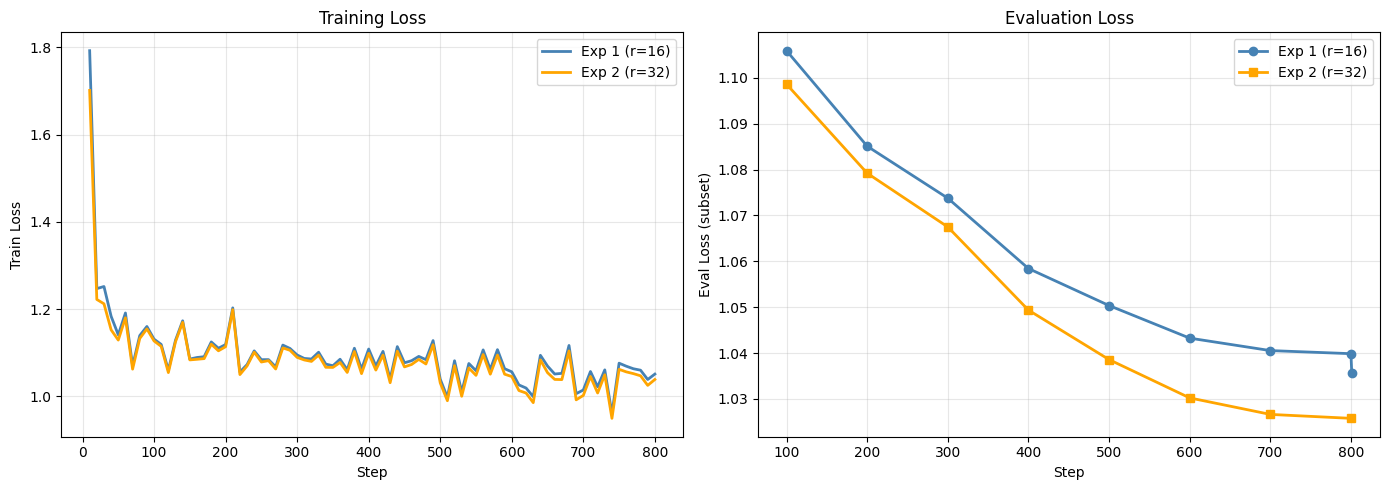

Plot saved: /content/drive/MyDrive/PGABL/outputs/finetune_evidence/sft_loss_comparison.png


In [10]:
import matplotlib.pyplot as plt

def extract_curves(log_history):
    train = [(e['step'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]
    eval_ = [(e['step'], e['eval_loss']) for e in log_history if 'eval_loss' in e]
    return train, eval_

e1_train, e1_eval = extract_curves(result_exp1['log_history'])
e2_train, e2_eval = extract_curves(result_exp2['log_history'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train loss
axes[0].plot([s for s,_ in e1_train], [l for _,l in e1_train], label='Exp 1 (r=16)', color='steelblue', linewidth=2)
axes[0].plot([s for s,_ in e2_train], [l for _,l in e2_train], label='Exp 2 (r=32)', color='orange', linewidth=2)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Eval loss
axes[1].plot([s for s,_ in e1_eval], [l for _,l in e1_eval], marker='o', label='Exp 1 (r=16)', color='steelblue', linewidth=2)
axes[1].plot([s for s,_ in e2_eval], [l for _,l in e2_eval], marker='s', label='Exp 2 (r=32)', color='orange', linewidth=2)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Eval Loss (subset)')
axes[1].set_title('Evaluation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plot_path = EVIDENCE_DIR / 'sft_loss_comparison.png'
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'Plot saved: {plot_path}')

In [11]:
# Comparison table
print('=' * 70)
print('COMPARISON TABLE')
print('=' * 70)
print(f'{"Metric":30s} | {"Exp 1 (r=16)":15s} | {"Exp 2 (r=32)":15s}')
print('-' * 70)
print(f'{"LoRA rank":30s} | {result_exp1["config"]["lora_r"]:15d} | {result_exp2["config"]["lora_r"]:15d}')
print(f'{"LoRA alpha":30s} | {result_exp1["config"]["lora_alpha"]:15d} | {result_exp2["config"]["lora_alpha"]:15d}')
print(f'{"Trainable params":30s} | {result_exp1["trainable_params"]:>15,} | {result_exp2["trainable_params"]:>15,}')
print(f'{"Training time (min)":30s} | {result_exp1["train_seconds"]/60:15.1f} | {result_exp2["train_seconds"]/60:15.1f}')

final_train_loss_e1 = e1_train[-1][1] if e1_train else float('nan')
final_train_loss_e2 = e2_train[-1][1] if e2_train else float('nan')
print(f'{"Final train loss":30s} | {final_train_loss_e1:15.4f} | {final_train_loss_e2:15.4f}')
print(f'{"Final eval loss":30s} | {result_exp1["final_eval_loss"]:15.4f} | {result_exp2["final_eval_loss"]:15.4f}')
print('=' * 70)

# Pick winner: lowest final eval loss
if result_exp1['final_eval_loss'] <= result_exp2['final_eval_loss']:
    winner = result_exp1
    loser = result_exp2
    reason = 'baseline dengan rank 16 mencapai eval_loss lebih rendah atau setara — kapasitas baseline sudah cukup untuk dataset ini dan menghindari risiko overfitting yang lebih tinggi pada rank 32'
else:
    winner = result_exp2
    loser = result_exp1
    reason = 'variation dengan rank 32 mencapai eval_loss lebih rendah — dataset menerima manfaat dari kapasitas LoRA yang lebih besar tanpa overfit signifikan'

print(f'\nWinner: {winner["name"]} (final eval_loss = {winner["final_eval_loss"]:.4f})')
print(f'Rationale: {reason}')

# Simpan hasil ringkas
comparison_summary = {
    'exp1': {'name': result_exp1['name'], 'config': result_exp1['config'], 'final_eval_loss': result_exp1['final_eval_loss'], 'train_seconds': result_exp1['train_seconds']},
    'exp2': {'name': result_exp2['name'], 'config': result_exp2['config'], 'final_eval_loss': result_exp2['final_eval_loss'], 'train_seconds': result_exp2['train_seconds']},
    'winner': winner['name'],
    'winner_final_eval_loss': winner['final_eval_loss'],
    'winner_rationale': reason,
}
summary_path = EVIDENCE_DIR / 'sft_comparison_summary.json'
with open(summary_path, 'w') as f:
    json.dump(comparison_summary, f, indent=2, default=str)
print(f'\nSummary saved: {summary_path}')

COMPARISON TABLE
Metric                         | Exp 1 (r=16)    | Exp 2 (r=32)   
----------------------------------------------------------------------
LoRA rank                      |              16 |              32
LoRA alpha                     |              32 |              64
Trainable params               |      24,313,856 |      48,627,712
Training time (min)            |             1.1 |            73.8
Final train loss               |          1.0510 |          1.0386
Final eval loss                |          1.0357 |          1.0258

Winner: exp2_variation_r32 (final eval_loss = 1.0258)
Rationale: variation dengan rank 32 mencapai eval_loss lebih rendah — dataset menerima manfaat dari kapasitas LoRA yang lebih besar tanpa overfit signifikan

Summary saved: /content/drive/MyDrive/PGABL/outputs/finetune_evidence/sft_comparison_summary.json


---

## Section 8 — Push Winner ke HuggingFace Hub

Winner adapter di-reload, di-merge dengan base model, lalu di-push sebagai **`merged_16bit`** ke HuggingFace Hub (public repository). Format `merged_16bit` kompatibel dengan semua downstream loader (Unsloth reload, transformers, vLLM) sehingga chatbot RAG di tahap berikutnya bisa langsung memuat model tanpa perlu apply adapter secara manual.

In [12]:
HF_REPO_SFT = f'{HF_USERNAME}/PGABL-Llama-3.2-3B-SFT'
print(f'Target HF repo: {HF_REPO_SFT}')
print(f'Winner adapter path: {winner["adapter_path"]}')

# Load LANGSUNG dari direktori adapter winner -> Unsloth memuat base + LoRA sebagai
# PEFT model yang proper. PENTING: kalau pakai from_pretrained(BASE) + load_adapter,
# save_pretrained_merged tidak mengenalinya sebagai model yang bisa di-merge dan hanya
# menyimpan adapter (bukan merged_16bit).
print(f'\nLoading winner adapter (base + LoRA)...')
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=winner['adapter_path'],
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    token=HF_TOKEN,
)
print('Winner adapter loaded (base + LoRA).')

Target HF repo: nazhifsetya-merpati/PGABL-Llama-3.2-3B-SFT
Winner adapter path: /content/drive/MyDrive/PGABL/checkpoints/sft/exp2_variation_r32_adapter

Loading winner adapter (base + LoRA)...
==((====))==  Unsloth 2026.7.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load /content/drive/MyDrive/PGABL/checkpoints/sft/exp2_variation_r32_adapter as a legacy tokenizer.
Unsloth 2026.7.2 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Winner adapter loaded (base + LoRA).


In [13]:
# Push merged 16-bit ke HuggingFace Hub
# Merge dilakukan ke disk lokal dulu (save_pretrained_merged), baru di-upload via HfApi.
# Pendekatan dua langkah ini kompatibel lintas versi Unsloth/Transformers dan
# menghasilkan artefak yang identik dengan push_to_hub_merged (bobot merged_16bit penuh).
import time
from huggingface_hub import HfApi

MERGED_DIR = '/content/merged_16bit'

# Step 1: merge adapter ke base model + simpan 16-bit ke disk lokal
print(f'Step 1/2: Merge adapter + save 16-bit ke {MERGED_DIR} ...')
t0 = time.time()
model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method='merged_16bit',
)
print(f'  Merge + save selesai dalam {(time.time() - t0) / 60:.1f} min')

# Step 2: upload folder hasil merge ke HF Hub (public) via API resmi huggingface_hub.
# delete_patterns membersihkan sisa file adapter kalau repo sebelumnya adapter-only,
# supaya repo akhir murni merged_16bit (tidak campur adapter + full weights).
print(f'\nStep 2/2: Upload ke {HF_REPO_SFT} (public, ~6 GB, estimasi 5-10 menit) ...')
t0 = time.time()
api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=HF_REPO_SFT, repo_type='model', private=False, exist_ok=True)
api.upload_folder(
    folder_path=MERGED_DIR,
    repo_id=HF_REPO_SFT,
    repo_type='model',
    commit_message='Upload PGABL SFT winner (merged_16bit)',
    delete_patterns=['adapter_config.json', 'adapter_model.safetensors'],
)
push_seconds = time.time() - t0
print(f'\nPush done in {push_seconds / 60:.1f} min')
print(f'Model URL: https://huggingface.co/{HF_REPO_SFT}')

Step 1/2: Merge adapter + save 16-bit ke /content/merged_16bit ...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/merged_16bit/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [05:20<00:00, 160.09s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [01:43<00:00, 51.99s/it]


Unsloth: Merge process complete. Saved to `/content/merged_16bit`
  Merge + save selesai dalam 7.2 min

Step 2/2: Upload ke nazhifsetya-merpati/PGABL-Llama-3.2-3B-SFT (public, ~6 GB, estimasi 5-10 menit) ...

Push done in 1.7 min
Model URL: https://huggingface.co/nazhifsetya-merpati/PGABL-Llama-3.2-3B-SFT


In [14]:
# Verifikasi model repo accessible + public
repo_info = hf_api.repo_info(repo_id=HF_REPO_SFT, repo_type='model')
print(f'Repo verified:')
print(f'  ID: {repo_info.id}')
print(f'  Private: {repo_info.private}')
print(f'  Last modified: {repo_info.last_modified}')
print(f'  Files: {len(repo_info.siblings)}')
assert not repo_info.private, 'Repo terdeteksi Private — WAJIB Public per rubric.'

Repo verified:
  ID: nazhifsetya-merpati/PGABL-Llama-3.2-3B-SFT
  Private: False
  Last modified: 2026-07-13 13:02:40+00:00
  Files: 9


---

## Section 9 — Save `link_huggingface.txt`

File `link_huggingface.txt` adalah salah satu deliverable wajib rubric. Diletakkan di working directory `/content/` supaya bisa di-download bersamaan dengan notebook.

In [15]:
sft_url = f'https://huggingface.co/{HF_REPO_SFT}'
grpo_url_placeholder = f'https://huggingface.co/{HF_USERNAME}/PGABL-Llama-3.2-3B-GRPO'

link_content = f'''SFT Model:  {sft_url}
GRPO Model: {grpo_url_placeholder}
'''

# Save ke working dir Colab + Drive
link_path_local = Path('/content/link_huggingface.txt')
link_path_drive = DRIVE_ROOT / 'link_huggingface.txt'

for p in (link_path_local, link_path_drive):
    p.write_text(link_content, encoding='utf-8')
    print(f'Saved: {p}')

print('\n--- link_huggingface.txt content ---')
print(link_content)
print('Catatan: URL GRPO adalah placeholder — akan di-update setelah GRPO notebook di-run.')

Saved: /content/link_huggingface.txt
Saved: /content/drive/MyDrive/PGABL/link_huggingface.txt

--- link_huggingface.txt content ---
SFT Model:  https://huggingface.co/nazhifsetya-merpati/PGABL-Llama-3.2-3B-SFT
GRPO Model: https://huggingface.co/nazhifsetya-merpati/PGABL-Llama-3.2-3B-GRPO

Catatan: URL GRPO adalah placeholder — akan di-update setelah GRPO notebook di-run.


---

## Ringkasan

Notebook ini menuntaskan tahap fine-tuning K1 (Basic + Skilled) untuk chatbot legal berbasis RAG.

**Yang dicapai:**
1. Load `Ichsan2895/alpaca-gpt4-indonesian` dan verifikasi chat template Llama-3 (5 special tokens present).
2. Fine-tuning **dua eksperimen** dengan LoRA di MHA + FFN via Unsloth 4-bit QLoRA — masing-masing 800 SFTTrainer steps dengan eval setiap 100 steps.
3. Analisis komparatif train/eval loss antar eksperimen dengan justifikasi pemilihan winner berbasis eval_loss dan generalisasi.
4. Push winner ke Hugging Face Hub sebagai `merged_16bit` (public repository).
5. Deliverable `link_huggingface.txt` disiapkan.

**Tahap berikutnya:** GRPO (Group Relative Policy Optimization) di notebook `GRPO_submission_PGABL_Nazhif_Setya_Nugroho.ipynb` — meningkatkan model dari Skilled ke Advanced dengan 4 reward function (format `<think>` tag, reasoning length, correctness, language) untuk mengajarkan reasoning terstruktur dalam Bahasa Indonesia.